In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [5]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


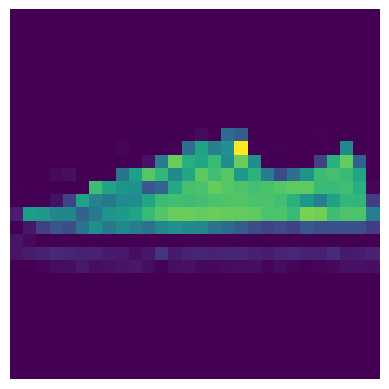

In [48]:
image = images[6]

plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [11]:
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

In [49]:
print(classes[labels[6]])

horse


In [25]:
import sys
import os

In [33]:
sys.path.append(os.path.abspath(r"C:\Users\olaaz\Documents\AI Roadmap\week27-building-real-networks\week38-cnn\day3\prepare-cifar-10+ build the CNN\models\__pycache__\cnn.py"))

In [50]:
project_dir = os.path.abspath(
    r"C:\Users\olaaz\Documents\AI Roadmap\week27-building-real-networks"
    r"\week38-cnn\day3\prepare-cifar-10+ build the CNN"
)

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

from models.cnn import SimpleCNN

model = SimpleCNN()

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [51]:
images_for_model = torch.nn.functional.interpolate(
    images.repeat(1, 3, 1, 1),
    size=(32, 32),
    mode="bilinear",
    align_corners=False
)
output = model(images_for_model)

print(output.shape)

torch.Size([64, 10])
